# **____Section 1____ **

## Section 1: Load & Validate Data
**Dataset**: CICIDS 2017
**Objective**: Load, merge, and validate raw network data

## Necessary Importation

Load all the necessary libraries before starting any work.

pandas and numpy for data manipulation
matplotlib and seaborn for visualization
warnings to hide unnecessary messages during execution

In [6]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## 1/1 Importation and download dataset

Purpose : Define the paths where data is read from and where results are saved.

In [10]:
DATA_PATH    = '/kaggle/input/datasets/yashpotdarpy/cicids-2017'
OUTPUT_PATH  = '/kaggle/working/'

print('Imports is OKay ! ')
print(f'Dossier data    : {DATA_PATH}')#verifaction 
print(f'Dossier output  : {OUTPUT_PATH}')

Imports is OKay ! 
Dossier data    : /kaggle/input/datasets/yashpotdarpy/cicids-2017
Dossier output  : /kaggle/working/


##  1/2 Exploring columns of th dataset files

The dataset is composed of 8 files . Each file contains attacks detected in 4 days.

In [11]:
files = sorted(glob.glob(os.path.join(DATA_PATH, '*.csv')))

print(f' {len(files)} files founded ! :\n')
total_size = 0
for f in files:
    size_mb = os.path.getsize(f) / (1024 * 1024)
    total_size += size_mb
    print(f'   [{size_mb:6.1f} MB]  {os.path.basename(f)}')

print(f'\n   Total : {total_size:.1f} MB')

 8 files founded ! :

   [  73.6 MB]  Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
   [  73.3 MB]  Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
   [  55.6 MB]  Friday-WorkingHours-Morning.pcap_ISCX.csv
   [ 168.7 MB]  Monday-WorkingHours.pcap_ISCX.csv
   [  79.3 MB]  Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
   [  49.6 MB]  Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
   [ 128.8 MB]  Tuesday-WorkingHours.pcap_ISCX.csv
   [ 214.7 MB]  Wednesday-workingHours.pcap_ISCX.csv

   Total : 843.7 MB


## 1/3 Checking the consistency of the columns
this cellul is to check that all files .csv have the save name of columns ...

In [12]:
# Read only the header of each file (fast)
print('Verifying columns per file:\n')

columns_per_file = {}

for f in files:
    df_head = pd.read_csv(f, nrows=0)
    df_head.columns = df_head.columns.str.strip()  # remove spaces
    columns_per_file[os.path.basename(f)] = set(df_head.columns)
    print(f'   {os.path.basename(f)[:55]:<55} → {len(df_head.columns)} columns')

# Check if all files have identical columns
all_columns = list(columns_per_file.values())
common_columns = set.intersection(*all_columns)
union_columns = set.union(*all_columns)

print(f'\n Common columns across all files: {len(common_columns)}')

if len(common_columns) != len(union_columns):
    diff = union_columns - common_columns
    print(f' Columns missing in some files: {diff}')
else:
    print('All files have exactly the same columns, so we can merge it')

Verifying columns per file:

   Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv        → 79 columns
   Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv    → 79 columns
   Friday-WorkingHours-Morning.pcap_ISCX.csv               → 79 columns
   Monday-WorkingHours.pcap_ISCX.csv                       → 79 columns
   Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX → 79 columns
   Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv  → 79 columns
   Tuesday-WorkingHours.pcap_ISCX.csv                      → 79 columns
   Wednesday-workingHours.pcap_ISCX.csv                    → 79 columns

 Common columns across all files: 79
All files have exactly the same columns, so we can merge it


## 1/4 Chargement et fusion des fichiers (DataLoader)


In [13]:
# ── DataLoader Class (matches the Class Diagram)
class DataLoader:
    def __init__(self, data_source: str):
        self._data_source = data_source  # data_source: String

    def load_data(self) -> pd.DataFrame:
        """Loads and merges all CSV files from the folder."""
        files = sorted(glob.glob(os.path.join(self._data_source, '*.csv')))
        
        if not files:
            raise FileNotFoundError(f'No CSV files found in: {self._data_source}')

        dataframes = []

        for f in files:
            filename = os.path.basename(f)
            df_temp = pd.read_csv(f, encoding='utf-8', low_memory=False)
            df_temp.columns = df_temp.columns.str.strip()
            df_temp['source_file'] = filename

            dataframes.append(df_temp)

            print(f'   ✓ {filename:<55} {df_temp.shape[0]:>8,} rows')

        df = pd.concat(dataframes, ignore_index=True)

        print(f'\n Merge completed: {df.shape[0]:,} rows × {df.shape[1]} columns')
        return df

    def validate_data(self, df: pd.DataFrame) -> bool:
        """Validates structure and completeness. Returns True if valid."""
        print('\n Validating data...')
        errors = []

        if df is None or df.empty:
            errors.append('Empty dataset')

        if 'Label' not in df.columns:
            errors.append('Missing "Label" column')

        missing_rate = df.isnull().mean().max()
        if missing_rate > 0.5:
            errors.append(f'Too many missing values: {missing_rate:.1%}')

        if 'Label' in df.columns and df['Label'].nunique() < 2:
            errors.append('Less than 2 classes in "Label"')

        if errors:
            for e in errors:
                print(f'  {e}')
            return False

        print('   ✔ Structure OK')
        print(f'  ✔ {df["Label"].nunique()} classes detected')
        print(f'  ✔ Missing values rate: {missing_rate:.2%}')

        return True


# ── Execution
print('Loading files...\n')

loader = DataLoader(DATA_PATH)
df_raw = loader.load_data()

Loading files...

   ✓ Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv         225,745 rows
   ✓ Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv     286,467 rows
   ✓ Friday-WorkingHours-Morning.pcap_ISCX.csv                191,033 rows
   ✓ Monday-WorkingHours.pcap_ISCX.csv                        529,918 rows
   ✓ Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv  288,602 rows
   ✓ Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv   170,366 rows
   ✓ Tuesday-WorkingHours.pcap_ISCX.csv                       445,909 rows
   ✓ Wednesday-workingHours.pcap_ISCX.csv                     692,703 rows

 Merge completed: 2,830,743 rows × 80 columns


## 1.5 — Data validation

In [14]:
# Validation (Activity Diagram: "Validate data → Data valid?")
is_valid = loader.validate_data(df_raw)

if not is_valid:
    raise Exception('Invalid data — fix errors before continuing')

print('\n Proceeding to Section 2 (ETL) is allowed ')


 Validating data...
   ✔ Structure OK
  ✔ 15 classes detected
  ✔ Missing values rate: 0.05%

 Proceeding to Section 2 (ETL) is allowed 


# EDA — Exploratory Data Analysis

**E — Exploratory**

In [15]:
# ── E : Exploratory — General structure
print('═' * 55)
print('   E — EXPLORATORY : General Overview')
print('═' * 55)
print(f'  Shape        : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print(f'  Memory       : {df_raw.memory_usage(deep=True).sum() / 1024**2:.1f} MB')
print(f'  Column types :')
for dtype, count in df_raw.dtypes.value_counts().items():
    print(f'     {str(dtype):<12} → {count} columns')
print('═' * 55)
df_raw.head(3)

═══════════════════════════════════════════════════════
   E — EXPLORATORY : General Overview
═══════════════════════════════════════════════════════
  Shape        : 2,830,743 rows × 80 columns
  Memory       : 2078.1 MB
  Column types :
     int64        → 54 columns
     float64      → 24 columns
     object       → 2 columns
═══════════════════════════════════════════════════════


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,source_file
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv


**D — Data**

In [16]:
# ── D : Data — Content analysis
print('═' * 55)
print('   D — DATA : Content Analysis')
print('═' * 55)

# Class distribution
label_counts = df_raw['Label'].value_counts()
print('Class distribution:\n')
print(label_counts.to_string())
print(f'\n→ BENIGN : {label_counts.get("BENIGN", 0):,}')
print(f'→ ATTACK : {label_counts[label_counts.index != "BENIGN"].sum():,}')

# Missing values
missing = df_raw.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False).head(15)
print('\nMissing values :')
if missing.empty:
    print(' No missing values detected')
else:
    print(missing.to_string())

═══════════════════════════════════════════════════════
   D — DATA : Content Analysis
═══════════════════════════════════════════════════════
Class distribution:

Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11

→ BENIGN : 2,273,097
→ ATTACK : 557,646

Missing values :
Flow Bytes/s    1358


**Cellule A — Analysis**

═══════════════════════════════════════════════════════
   A — ANALYSIS : Visualization
═══════════════════════════════════════════════════════


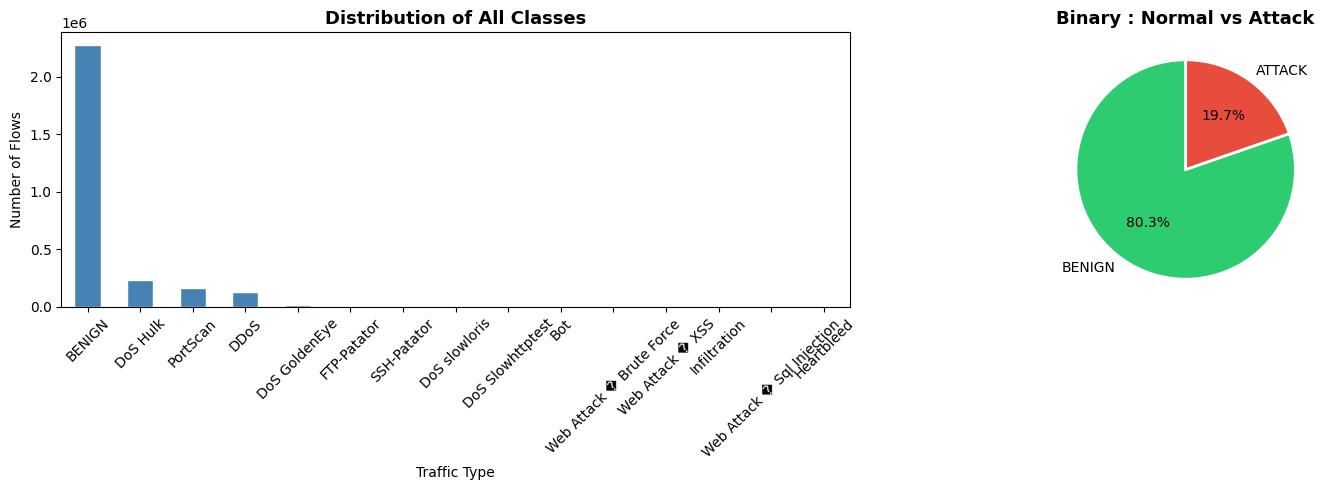

Graph saved as: class_distribution.png


In [17]:
# ── A : Analysis — Visual analysis
print('═' * 55)
print('   A — ANALYSIS : Visualization')
print('═' * 55)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1 : all classes
label_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of All Classes', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Traffic Type')
axes[0].set_ylabel('Number of Flows')
axes[0].tick_params(axis='x', rotation=45)

# Plot 2 : binary BENIGN vs ATTACK
binary = pd.Series({
    'BENIGN': label_counts.get('BENIGN', 0),
    'ATTACK': label_counts[label_counts.index != 'BENIGN'].sum()
})
colors = ['#2ecc71', '#e74c3c']
binary.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=colors,
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Binary : Normal vs Attack', fontsize=13, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graph saved as: class_distribution.png')

# ── Complete Diagnostic — summary of all issues

In [18]:
print("=" * 55)
print("   COMPLETE DATASET DIAGNOSTIC")
print("=" * 55)
print(f"\nShape          : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"Infinite values: {np.isinf(df_raw.select_dtypes(include='number')).sum().sum():,}")
print(f"Missing values : {df_raw.isnull().sum().sum():,}")
print(f"Duplicate rows : {df_raw.duplicated().sum():,}")
print(f"Constant cols  : {sum(df_raw[c].nunique() <= 1 for c in df_raw.columns)}")

benign = (df_raw['Label'] == 'BENIGN').sum()
attack = (df_raw['Label'] != 'BENIGN').sum()
ratio  = benign / attack
print(f"\nBENIGN/ATTACK ratio: {ratio:.1f}x")
print("Acceptable imbalance" if ratio <= 5 else "Highly imbalanced")
print("=" * 55)
print("Result → issues to fix in ETL")
print("=" * 55)

   COMPLETE DATASET DIAGNOSTIC

Shape          : 2,830,743 rows × 80 columns
Infinite values: 4,376
Missing values : 1,358
Duplicate rows : 256,479
Constant cols  : 8

BENIGN/ATTACK ratio: 4.1x
Acceptable imbalance
Result → issues to fix in ETL


# Save the merged raw dataset for next Step (ETL)

Purpose : Save the merged raw dataset so Section 2 (ETL) can load it directly.

In [19]:
save_path = OUTPUT_PATH + 'df_raw.csv'
df_raw.to_csv(save_path, index=False)

print(f' Raw dataset saved at: {save_path}')
print(f'   → {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print('\n Section 1 completed -----> Section2')

 Raw dataset saved at: /kaggle/working/df_raw.csv
   → 2,830,743 rows × 80 columns

 Section 1 completed -----> Section2
